In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

In [3]:
X = pd.get_dummies(
    df.drop(columns=["Bio_Oil_Yield"]),
    drop_first=True
)

y = df["Bio_Oil_Yield"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
%pip install xgboost

In [7]:
import xgboost

print(xgboost.__version__)

3.3.0


In [8]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [9]:
xgb = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

In [10]:
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))

MAE : 1.7
RMSE: 2.63
R²  : 0.9497


In [11]:
train_pred = xgb.predict(X_train)

print("Training R²:",
      r2_score(y_train, train_pred))

print("Testing R²:",
      r2_score(y_test, y_pred))

Training R²: 0.9988557617621816
Testing R²: 0.9497000165082123


#### LightBGM

In [ ]:
%pip install lightgbm

In [16]:
from lightgbm import LGBMRegressor

In [18]:
import re

def sanitize_lightgbm_feature_names(df):
    clean_df = df.copy()
    clean_df.columns = [
        re.sub(r"[^A-Za-z0-9_]", "_", str(col))
        for col in clean_df.columns
    ]
    return clean_df

X_train = sanitize_lightgbm_feature_names(X_train)
X_test = sanitize_lightgbm_feature_names(X_test)

lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001167 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1014
[LightGBM] [Info] Number of data points in the train set: 572, number of used features: 17
[LightGBM] [Info] Start training from score 38.908636
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [19]:
train_pred = lgbm.predict(X_train)

print("Training R²:",
      r2_score(y_train, train_pred))

print("Testing R²:",
      r2_score(y_test, y_pred))

Training R²: 0.9824648540815725
Testing R²: 0.9518674898784973


#### CatBoost

In [ ]:
%pip install catboost

In [21]:
from catboost import CatBoostRegressor

In [22]:
cat = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

In [24]:
cat.fit(X_train, y_train)
y_pred = cat.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 1.81
RMSE: 2.38
R²  : 0.9589


In [25]:
train_pred = cat.predict(X_train)

print("Training R²:",
      r2_score(y_train, train_pred))

print("Testing R²:",
      r2_score(y_test, y_pred))

Training R²: 0.9773285234985913
Testing R²: 0.9589320807550109


#### Neural Networks

In [26]:
from sklearn.neural_network import MLPRegressor

In [27]:
mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

In [28]:
mlp.fit(X_train_scaled, y_train)

c:\Users\Lenovo\OneDrive\Desktop\bio-oil-yield-prediction\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'."

In [30]:
y_pred = mlp.predict(X_test_scaled)

In [31]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 1.92
RMSE: 3.68
R²  : 0.9015


In [32]:
train_pred = mlp.predict(X_train_scaled)

print("Training R²:",
      r2_score(y_train, train_pred))

print("Testing R²:",
      r2_score(y_test, y_pred))

Training R²: 0.9765847452535895
Testing R²: 0.9014688458429461


### Comparing Model Results

In [ ]:
results = []

In [33]:
results = [
    {
        "Model": "Linear Regression",
        "MAE": 3.85,
        "RMSE": 5.92,
        "Test_R2": 0.7454,
        "Train_R2": np.nan
    },
    {
        "Model": "Random Forest",
        "MAE": 2.24,
        "RMSE": 3.36,
        "Test_R2": 0.9177,
        "Train_R2": 0.9740
    },
    {
        "Model": "XGBoost",
        "MAE": 1.6989,
        "RMSE": 2.6289,
        "Test_R2": 0.9497,
        "Train_R2": 0.9989
    },
    {
        "Model": "LightGBM",
        "MAE": 1.90,
        "RMSE": 2.57,
        "Test_R2": 0.9519,
        "Train_R2": 0.9825
    },
    {
        "Model": "CatBoost",
        "MAE": 1.81,
        "RMSE": 2.38,
        "Test_R2": 0.9589,
        "Train_R2": 0.9773
    },
    {
        "Model": "Neural Network",
        "MAE": 1.92,
        "RMSE": 3.68,
        "Test_R2": 0.9015,
        "Train_R2": 0.9766
    }
]

In [34]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Test_R2",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,MAE,RMSE,Test_R2,Train_R2
0,CatBoost,1.8100,2.3800,0.9589,0.9773
1,LightGBM,1.9000,2.5700,0.9519,0.9825
2,XGBoost,1.6989,2.6289,0.9497,0.9989
3,Random Forest,2.2400,3.3600,0.9177,0.9740
4,Neural Network,1.9200,3.6800,0.9015,0.9766
5,Linear Regression,3.8500,5.9200,0.7454,NaN


In [ ]:
import os

output_dir = os.path.join("..", "results")
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "model_comparison.csv")
results_df.to_csv(output_file, index=False)
print(f"Saved model comparison to {output_file}")

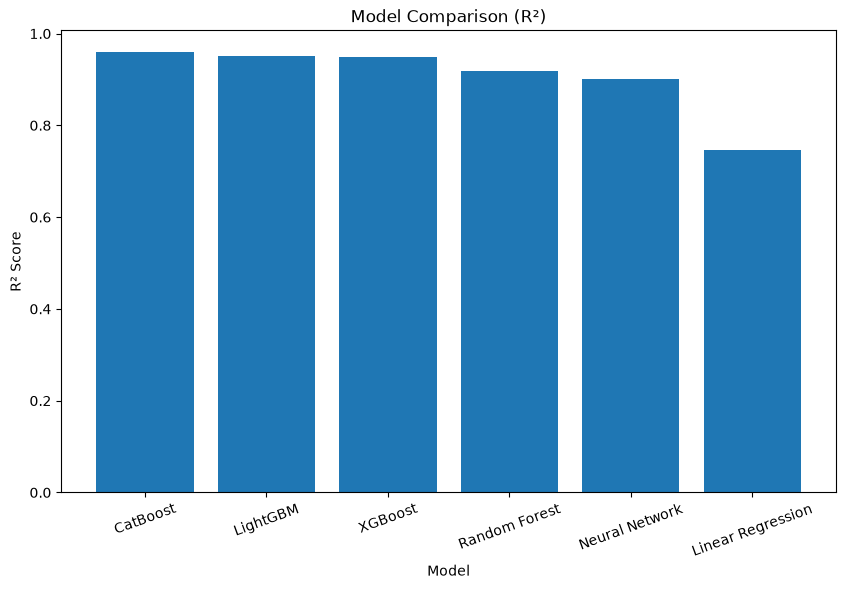

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    results_df["Model"],
    results_df["Test_R2"]
)

plt.title("Model Comparison (R²)")
plt.ylabel("R² Score")
plt.xlabel("Model")

plt.xticks(rotation=20)

plt.show()

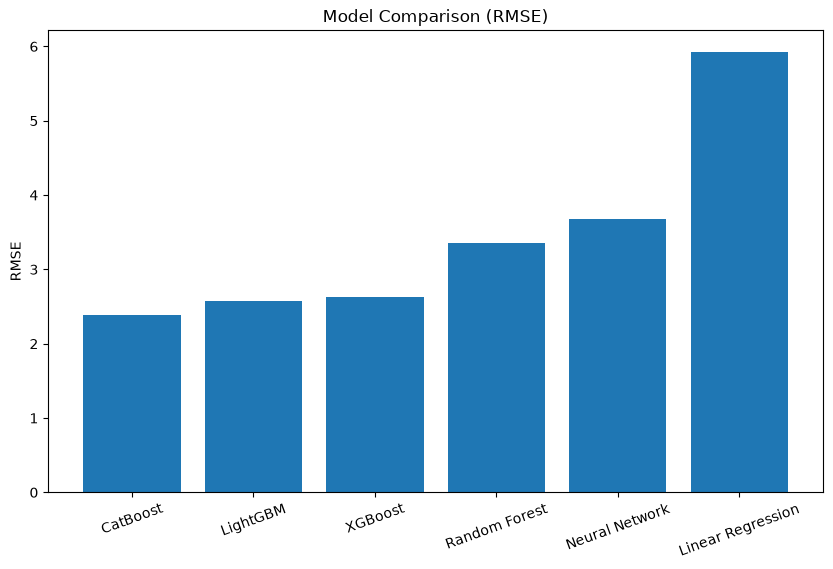

In [36]:
plt.figure(figsize=(10,6))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

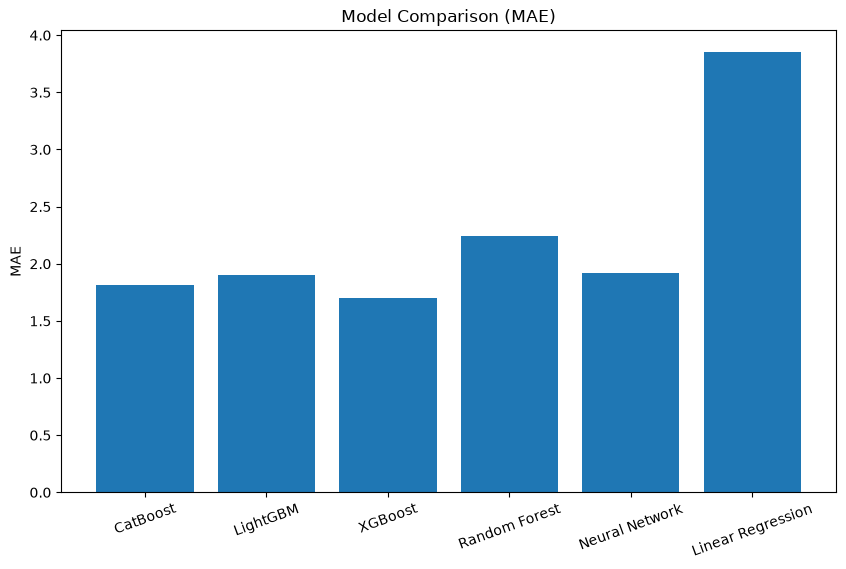

In [37]:
plt.figure(figsize=(10,6))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("Model Comparison (MAE)")
plt.ylabel("MAE")

plt.xticks(rotation=20)

plt.show()

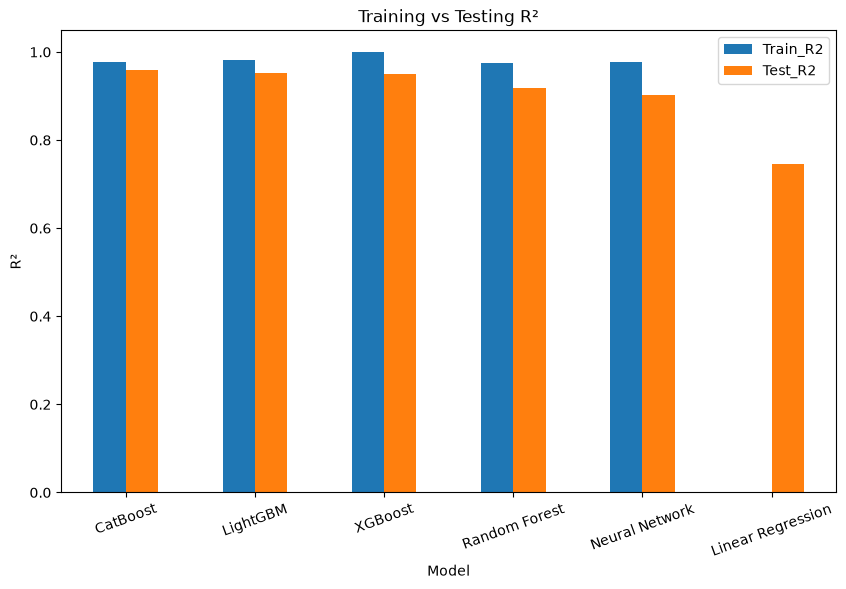

In [38]:
comparison = results_df.set_index("Model")[["Train_R2", "Test_R2"]]

comparison.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Training vs Testing R²")

plt.ylabel("R²")

plt.xticks(rotation=20)

plt.show()

## Final Model Selection

Six regression algorithms were evaluated for predicting bio-oil yield from biomass pyrolysis data.

Among all evaluated models, CatBoost achieved the best predictive performance with:

- R² = 0.9589
- RMSE = 2.38
- MAE = 1.81

CatBoost also exhibited a small gap between training and testing performance, indicating strong generalization and minimal overfitting.

Therefore, CatBoost was selected as the final predictive model for this study.